# IMPORTING & LOADING THE LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
df = pd.read_excel("online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# DATA KNOWLEDGE

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.shape

(525461, 8)

In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

# DATA CLEANING

## REMOVE NULL CUSTOMER ID VALUES

In [7]:
df = df.dropna(subset=["Customer ID"])

## REMOVE NEGATIVE VALUES OF PRICE AND QUANTITY

In [8]:
df = df[df["Quantity"]>0]

In [9]:
df = df[df["Price"]>0]

## RENAMING COLUMN NAME WITH SPACES TO W/O SPACES

In [10]:
df = df.rename(columns = {"Customer ID":"CustomerID"})

## CREATE A NEW COLUMN TOTAL PRICE

In [11]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

## REMOVING ALL CANCELLED INVOICES

In [12]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

## RECHECKING DATA 

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407664 non-null  object        
 1   StockCode    407664 non-null  object        
 2   Description  407664 non-null  object        
 3   Quantity     407664 non-null  int64         
 4   InvoiceDate  407664 non-null  datetime64[ns]
 5   Price        407664 non-null  float64       
 6   CustomerID   407664 non-null  float64       
 7   Country      407664 non-null  object        
 8   TotalPrice   407664 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.1+ MB


In [14]:
df.describe()

,Quantity,InvoiceDate,Price,CustomerID,TotalPrice
count,407664.000000,407664,407664.000000,407664.000000,407664.000000
mean,13.585585,2010-07-01 10:15:11.871688192,3.294438,15368.592598,21.664909
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-03-26 14:01:00,1.250000,13997.000000,4.950000
50%,5.000000,2010-07-09 15:47:00,1.950000,15321.000000,11.900000
75%,12.000000,2010-10-14 17:09:00,3.750000,16812.000000,19.500000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000
std,96.840747,NaN,34.757965,1679.762138,77.150058


In [15]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [16]:
df.shape

(407664, 9)

In [17]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# RFM FEATURE ENGINEERING

## DECLARING A REFERENCE DATE 

In [18]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days = 1)

## DECLARING RFM VARIABLES

In [19]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

## RENAMING THE COLUMNS TO RFM

In [20]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

In [21]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [22]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2048.238236
std,1701.200176,96.860633,8.170213,8914.481280
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.987500
50%,15350.500000,53.000000,2.000000,706.020000
75%,16834.250000,136.000000,5.000000,1723.142500
max,18287.000000,374.000000,205.000000,349164.350000


## RFM SCORING

## CREATE RFM SCORES :
## LOW RECENCY - GOOD
## HIGH F - GOOD
## HIGH M - GOOD

In [23]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [24]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [25]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# combine the scores into one column 

In [26]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [27]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) + 
    rfm['F_score'].astype(str) + 
    rfm['M_score'].astype(str)
)

In [28]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,165,11,372.86,2,5,2,252
1,12347.0,3,2,1323.32,5,2,4,524
2,12348.0,74,1,222.16,2,1,1,211
3,12349.0,43,3,2671.14,3,3,5,335
4,12351.0,11,1,300.93,5,1,2,512


# CREATE CUSTOMER SEGMENT

In [29]:
# def segment_customer(row):
#     if row['R_score'] == 5 and row['F_score'] >= 4:
#         return 'Loyal Customers'
#     elif row['R_score'] >= 4 and row['F_score'] <= 2:
#         return 'New Customers'
#     elif row['R_score'] <= 2 and row['F_score'] >= 4:
#         return 'At Risk'
#     elif row['R_score'] <= 2:
#         return 'Lost Customers'
#     else:
#         return 'Average Customers'

# rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'] = 'Average Customers'

rfm.loc[(rfm['R_score'] == 5) & (rfm['F_score'] >= 4), 'Segment'] = 'Loyal Customers'

rfm.loc[(rfm['R_score'] >= 4) & (rfm['F_score'] <= 2), 'Segment'] = 'New Customers'

rfm.loc[(rfm['R_score'] <= 2) & (rfm['F_score'] >= 4), 'Segment'] = 'At Risk'

rfm.loc[(rfm['R_score'] <= 2), 'Segment'] = 'Lost Customers'

In [30]:
rfm['Segment'].value_counts()

Segment
Lost Customers       1703
Average Customers    1579
Loyal Customers       663
New Customers         367
Name: count, dtype: int64

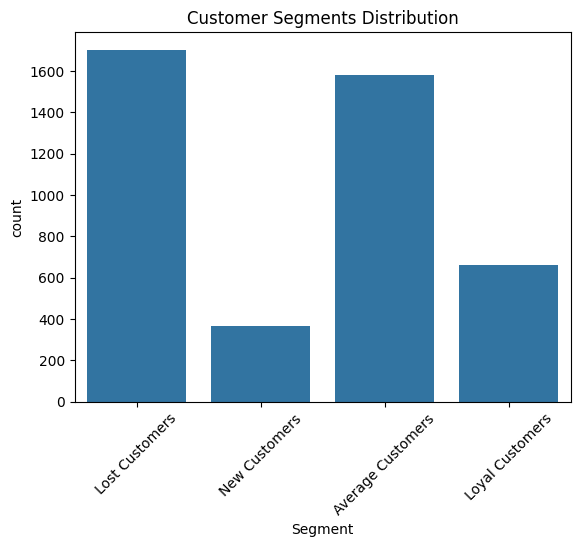

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segments Distribution")
plt.show()

In [32]:
# Since we don’t have future data, we define retention using:

#  Recency (how recently customer purchased)

# Logic:
# Low Recency → Active (retained)
# High Recency → Inactive (churned)

## Create Retention Flag

In [33]:
rfm['Retention_Status'] = np.where(rfm['Recency'] <= 30, 'Active', 'Churned')

## Retention by Segment

In [34]:
rfm.groupby(['Segment', 'Retention_Status']).size().unstack()

Retention_Status,Active,Churned
Segment,,
Average Customers,591.0,988.0
Lost Customers,NaN,1703.0
Loyal Customers,663.0,NaN
New Customers,315.0,52.0


## Visualize Retention

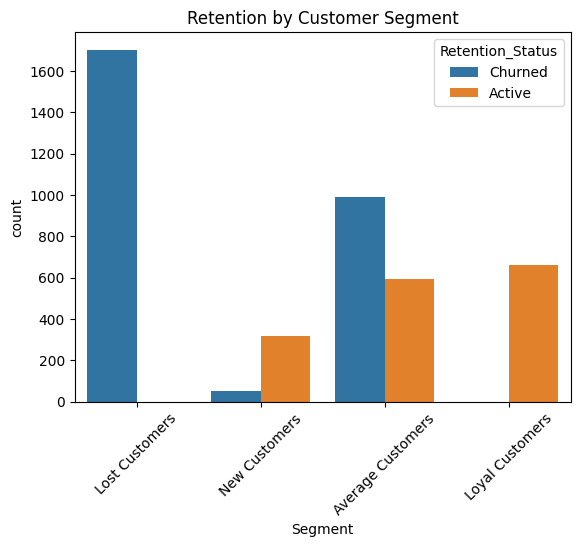

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', hue='Retention_Status', data=rfm)
plt.xticks(rotation=45)
plt.title("Retention by Customer Segment")
plt.show()

## Statistical Analysis

In [36]:
from scipy.stats import ttest_ind

high_freq = rfm[rfm['Frequency'] > rfm['Frequency'].median()]['Recency']
low_freq = rfm[rfm['Frequency'] <= rfm['Frequency'].median()]['Recency']

ttest_ind(high_freq, low_freq)

TtestResult(statistic=np.float64(-30.485798016323187), pvalue=np.float64(5.121496133564917e-185), df=np.float64(4310.0))

In [ ]:
# Interpretation:
# p-value < 0.05 → significant difference
# Means frequency affects retention

## Business Insights

In [ ]:
# 📌 Insight 1

# Lost customers show extremely high churn, indicating poor retention in low-engagement segments.

# 📌 Insight 2

# Loyal customers have the highest retention, proving that frequent and high-spending customers are more stable.

# 📌 Insight 3

# Average customers show mixed behavior and represent the best opportunity for retention improvement.

# 📌 Insight 4

# New customers are mostly active, indicating successful initial engagement.

# 📌 Insight 5 

# Statistical testing confirms that purchase frequency significantly impacts customer retention.

## BUSINESS RECOMMENDATIONS

In [ ]:
# Actionable Strategies:
#  Target At Risk / Average customers with personalized offers
#  Create loyalty programs for loyal customers
#  Re-engage lost customers with win-back campaigns
#  Encourage repeat purchases early (critical for retention)